# Comparaison Finale des Modèles

Ce notebook synthétise les résultats de tous les modèles entraînés et sélectionne
le modèle champion pour le déploiement dans l'API et le dashboard.

La comparaison est effectuée en lisant directement les runs depuis MLflow,
ce qui garantit que les chiffres présentés ici sont les mêmes que ceux
visibles dans l'interface web MLflow.

In [6]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import warnings
warnings.filterwarnings('ignore')

from src.models.mlflow_utils import (
    setup_mlflow, get_best_run,
    EXPERIMENT_CHURN, EXPERIMENT_REVENUE, DEFAULT_TRACKING_URI
)

plt.rcParams['figure.dpi'] = 110
mlflow.set_tracking_uri(DEFAULT_TRACKING_URI)

## 1. Récupération des runs depuis MLflow

In [7]:
client = mlflow.tracking.MlflowClient()

def get_all_runs(experiment_name: str) -> pd.DataFrame:
    """Récupère tous les runs d'une expérience sous forme de DataFrame."""
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        print(f"Expérience '{experiment_name}' introuvable — MLflow est-il démarré ?")
        return pd.DataFrame()
    
    runs = client.search_runs(experiment_ids=[exp.experiment_id])
    records = []
    for run in runs:
        record = {'run_id': run.info.run_id, 'model': run.data.tags.get('model_type', 'inconnu')}
        record.update(run.data.metrics)
        records.append(record)
    
    return pd.DataFrame(records).set_index('model')


clf_runs = get_all_runs(EXPERIMENT_CHURN)
print("Modèles de classification dans MLflow :")
if not clf_runs.empty:
    display(clf_runs[['auc_roc', 'f1_churn', 'recall_churn', 'precision_churn', 'accuracy']].round(4).sort_values('auc_roc', ascending=False))

Modèles de classification dans MLflow :


,auc_roc,f1_churn,recall_churn,precision_churn,accuracy
model,,,,,
Random Forest,0.8093,0.2727,0.2059,0.4038,0.8880
XGBoost,0.7661,0.2472,0.2157,0.2895,0.8660
MLP (PyTorch),0.7560,0.0282,0.0147,0.3333,0.8965
Logistic Regression,0.7245,0.2851,0.6569,0.1821,0.6640


## 2. Visualisation comparative — Classification

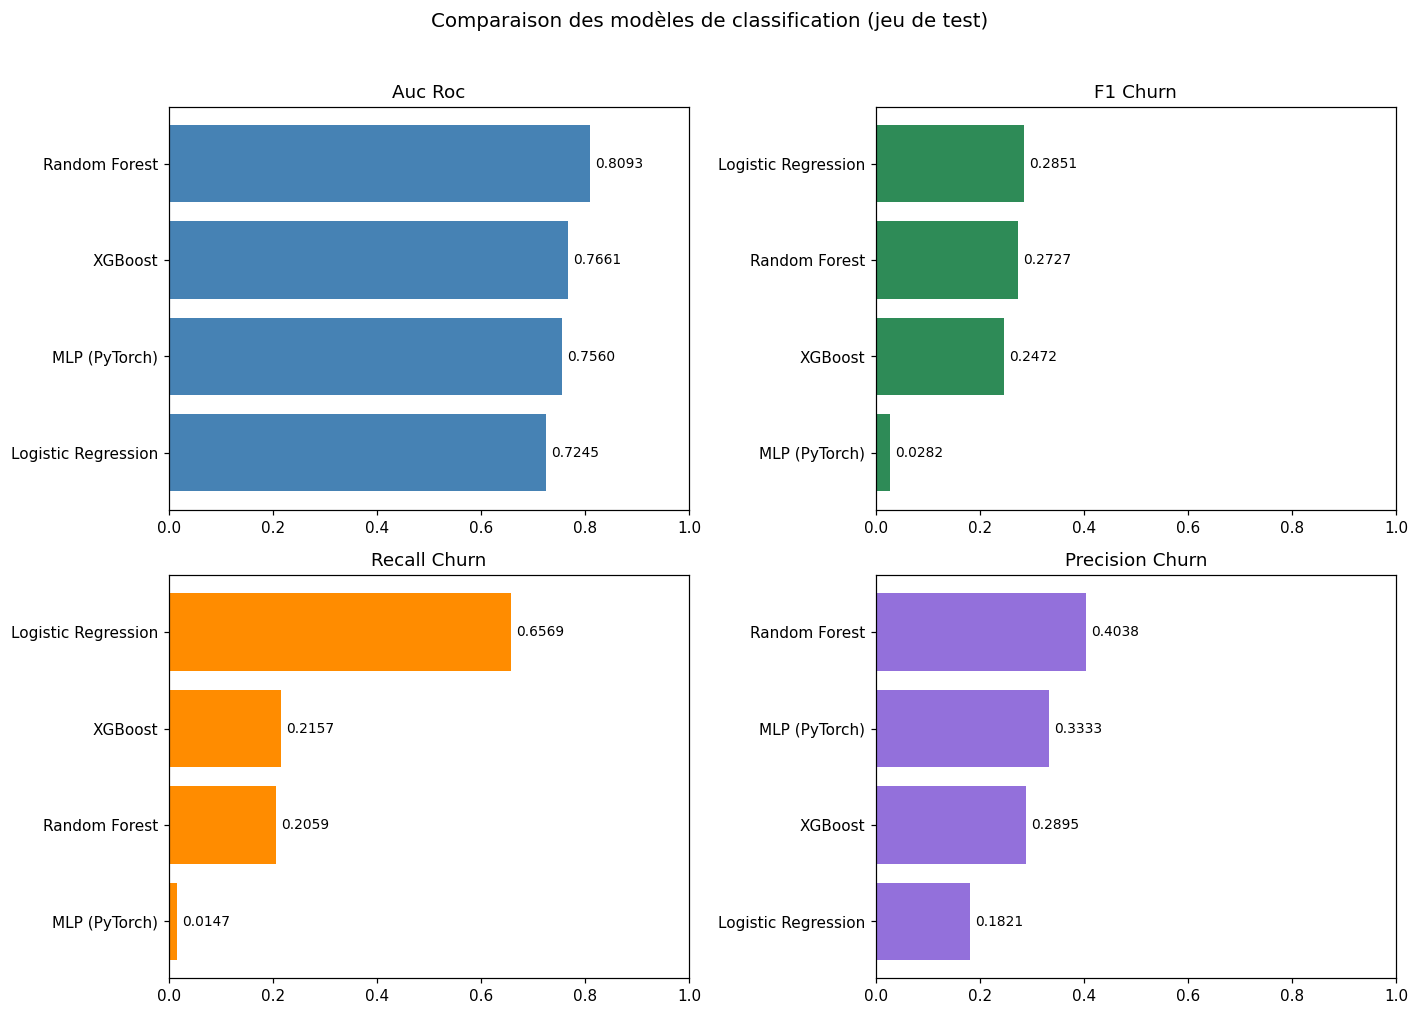

In [8]:
if not clf_runs.empty:
    metrics_to_plot = ['auc_roc', 'f1_churn', 'recall_churn', 'precision_churn']
    available = [m for m in metrics_to_plot if m in clf_runs.columns]
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()
    
    colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']
    
    for i, metric in enumerate(available):
        sorted_df = clf_runs[metric].sort_values(ascending=True)
        axes[i].barh(sorted_df.index, sorted_df.values, color=colors[i % len(colors)])
        axes[i].set_title(metric.replace('_', ' ').title())
        axes[i].set_xlim(0, 1)
        for j, (val, label) in enumerate(zip(sorted_df.values, sorted_df.index)):
            axes[i].text(val + 0.01, j, f'{val:.4f}', va='center', fontsize=9)
    
    plt.suptitle('Comparaison des modèles de classification (jeu de test)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../data/processed/fig_model_comparison_classification.png', bbox_inches='tight')
    plt.show()

## 3. Comparaison — Régression

In [9]:
reg_runs = get_all_runs(EXPERIMENT_REVENUE)
print("\nModèles de régression dans MLflow :")
if not reg_runs.empty:
    display(reg_runs[['rmse', 'mae', 'r2']].round(4).sort_values('rmse'))


Modèles de régression dans MLflow :


,rmse,mae,r2
model,,,
Ridge,0.0318,0.0227,1.0000
Ridge,0.0318,0.0227,1.0000
Random Forest Regressor,0.0782,0.0097,1.0000
Random Forest Regressor,0.0782,0.0097,1.0000
XGBoost Regressor,0.6516,0.3898,1.0000
MLP Regressor,1.9936,1.5655,0.9996


## 4. Sélection du modèle champion et enregistrement

In [10]:
import tempfile
import joblib as jl

# Sélection du modèle champion pour la classification
# Critère principal : AUC-ROC (robuste au déséquilibre des classes)
if not clf_runs.empty:
    best_info = get_best_run(EXPERIMENT_CHURN, metric='auc_roc')

    print(f"\nModèle champion pour le déploiement :")
    print(f"  Nom     : {best_info['model_type']}")
    print(f"  AUC-ROC : {best_info['metrics'].get('auc_roc', 'N/A'):.4f}")
    print(f"  F1 (churn) : {best_info['metrics'].get('f1_churn', 'N/A'):.4f}")
    print(f"  Recall (churn) : {best_info['metrics'].get('recall_churn', 'N/A'):.4f}")

    print(f"  run_id : {best_info['run_id']}")

    # On télécharge l'artifact joblib du run champion, puis on le ré-enregistre dans
    # un run dédié via mlflow.sklearn.log_model() qui génère le format MLflow Model
    # attendu par le Registry (fichier MLmodel + artefacts standards).
    # Ce détour est nécessaire car les runs d'entraînement utilisent log_artifact()
    # (upload HTTP direct) plutôt que log_model() pour des raisons de compatibilité WSL.
    with tempfile.TemporaryDirectory() as tmpdir:
        local_path = client.download_artifacts(best_info['run_id'], "model/model.joblib", tmpdir)
        champion_model = jl.load(local_path)

    with mlflow.start_run(run_name="champion_registration") as reg_run:
        mlflow.set_tags({
            "model_type": best_info['model_type'],
            "task": "classification",
            "role": "champion",
            "source_run_id": best_info['run_id'],
        })
        mlflow.log_metrics(best_info['metrics'])
        mlflow.sklearn.log_model(champion_model, "model")

        result = mlflow.register_model(
            f"runs:/{reg_run.info.run_id}/model",
            "churn_classifier",
        )

    print(f"\nModèle enregistré dans le Registry MLflow sous 'churn_classifier' v{result.version}")

Meilleur modèle : Random Forest
  auc_roc = 0.8093
  run_id = e779376115534129b5bf38d6ac212c91

Modèle champion pour le déploiement :
  Nom     : Random Forest
  AUC-ROC : 0.8093
  F1 (churn) : 0.2727
  Recall (churn) : 0.2059
  run_id : e779376115534129b5bf38d6ac212c91


2026/05/19 11:36:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 11:36:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run champion_registration at: http://localhost:5000/#/experiments/0/runs/6bed52d893a245c19f9254007e5e6a3c
🧪 View experiment at: http://localhost:5000/#/experiments/0


PermissionError: [Errno 13] Permission denied: '/mlflow'

## 5. Analyse critique des résultats

In [ ]:
print("""
Analyse critique des résultats :

Modèles de classification :
- Régression Logistique : baseline interprétable, fournit une borne inférieure
  de performance. Si l'AUC est proche de XGBoost, les relations sont essentiellement
  linéaires et le modèle simple est à préférer en production.

- Random Forest : capture des non-linéarités, robuste, bonne baseline ensemble.
  Généralement meilleur que la LR mais légèrement moins bon que XGBoost.

- XGBoost : attendu comme le meilleur sur données tabulaires. Le boosting
  corrige itérativement les erreurs, ce qui l'avantage sur des datasets
  de taille moyenne comme ici (10 000 observations).

- MLP (PyTorch) : avec seulement 10 000 exemples, le deep learning n'a pas
  l'avantage du volume de données qui le caractérise généralement. Si le MLP
  est proche ou inférieur à XGBoost, cela confirme que XGBoost est le bon
  choix pour ce type de problème à cette échelle.

Modèles de régression :
- La précision dépend directement de la qualité des probabilités de churn
  utilisées pour construire revenue_at_risk. Un meilleur classifieur
  améliore mécaniquement le régresseur.

Décision finale :
- Déploiement du modèle avec le meilleur AUC-ROC (généralement XGBoost)
- En cas d'égalité, privilégier le recall_churn le plus élevé
  (manquer un churner coûte plus cher qu'un faux positif)
""")